# M1 method


## From scratch

In [16]:
import pandas as pd
import numpy as np
from util.filter_data import filtering
from methods.decision_tree_scratch import DecisionTreeScratch

df1 = filtering('src/claims_train.csv', train=True)

def kfold_split(n_samples, k=5, seed=42):
    np.random.seed(seed)
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    return np.array_split(indices, k)


def cross_validate_tree(df, target_col, tree_class, features, k=5, seed=42, **tree_kwargs):
    folds = kfold_split(len(df), k=k, seed=seed)
    mse_scores = []
    best_tree = None
    best_mse = float("inf")

    for i in range(k):
        val_idx = folds[i]
        train_idx = np.setdiff1d(np.arange(len(df)), val_idx)

        # selcts features and target column
        X_train = df.iloc[train_idx][features].to_numpy()
        y_train = df.iloc[train_idx][target_col].to_numpy()
        X_val = df.iloc[val_idx][features].to_numpy()
        y_val = df.iloc[val_idx][target_col].to_numpy()

        # trains tree using the hyperparameters
        tree = tree_class(**tree_kwargs)
        tree.fit(X_train, y_train)

        # pruining
        tree.prune(X_val, y_val)

        # Evaluate validation MSE
        y_val_pred = tree.predict(X_val)
        mse = np.mean((y_val - y_val_pred)**2)
        mse_scores.append(mse)

        # Keep the best tree
        if mse < best_mse:
            best_mse = mse
            best_tree = tree

        print(f"Fold {i+1}/{k} - Validation MSE: {mse:.4f}")

    print(f"Best validation MSE: {best_mse:.4f}")
    return mse_scores, best_tree

c:\Users\takac\ITU\semester3\machine\machine-n-learnings-inc\util\filter_data.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Region', group_keys=False).apply(remove_outliers)


In [17]:
def predict_tree(tree, df, features):
    X = df[features].to_numpy()
    return tree.predict(X)


features = ["VehPower", "VehAge", "DrivAge", "BonusMalus", "Density"]

# Perform 5-fold CV and get the best tree
mse_scores, best_tree = cross_validate_tree(
    df=df1,
    target_col="Risk",
    tree_class=DecisionTreeScratch,
    features=features,
    k=5,
    max_depth=5,
    min_samples_split=20
)

# Predict a single row
single_row = df1.iloc[0:1]  # keep as DataFrame
pred_single = predict_tree(best_tree, single_row, features)
print(f"Predicted risk for single row: {pred_single[0]:.5f}")
# First 10 actual target values
actual_values = df1["Risk"].iloc[:10]
print("Actual risk values for first 10 rows:")
print(actual_values.values)


# Predict multiple rows
pred_batch = predict_tree(best_tree, df1.iloc[:10], features)
print("Predictions for first 10 rows:", pred_batch)

Fold 1/5 - Validation MSE: 0.0285
Fold 2/5 - Validation MSE: 0.0286
Fold 3/5 - Validation MSE: 0.0284
Fold 4/5 - Validation MSE: 0.0286
Fold 5/5 - Validation MSE: 0.0284
Best validation MSE: 0.0284
Predicted risk for single row: 0.21920
Actual risk values for first 10 rows:
[0.44779761 0.59454042 0.37738764 0.19304709 0.59454042 0.4276604
 0.08701661 0.08701661 0.10427201 0.0935331 ]
Predictions for first 10 rows: [0.21919506 0.23282468 0.18120818 0.26987773 0.35539316 0.21919506
 0.26987773 0.2019538  0.24901564 0.26987773]


## Using reference

# M2 method - Neural Network


## From scratch

In [18]:
from methods.neural_network_scratch import NeuralNetworkScratch
from util.filter_data import filtering
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df = filtering('src/claims_train.csv', alpha=2, gamma=0.1, train=True)
df_test = filtering('src/claims_test.csv', alpha=2, gamma=0.1, train=False)

Y = df['Risk'].values.astype(np.float32).reshape(-1, 1)
df_clean = df.drop(columns=["IDpol", "ClaimNb", "Exposure","Region",'Risk'])
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df_clean.select_dtypes(include=["object", "category"]).columns
X_cat = pd.get_dummies(df_clean[categorical_cols], drop_first=True)
df_clean = df_clean.drop(columns=categorical_cols)
X_final = np.hstack([df_clean, X_cat.values])

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final).astype(np.float32)


Y_test = df_test['Risk'].values.astype(np.float32).reshape(-1, 1)
df_clean_test = df_test.drop(columns=["IDpol", "ClaimNb", "Exposure","Region",'Risk'])
numeric_cols_test = df_clean_test.select_dtypes(include=["int64", "float64"]).columns
categorical_cols_test = df_clean_test.select_dtypes(include=["object", "category"]).columns

X_cat_test = pd.get_dummies(df_clean_test[categorical_cols_test], drop_first=True)
df_clean_test = df_clean_test.drop(columns=categorical_cols_test)
X_final_test = np.hstack([df_clean_test, X_cat_test.values])

# Feature scaling
scaler = StandardScaler()
X_scaled_test = scaler.fit_transform(X_final_test).astype(np.float32)



c:\Users\takac\ITU\semester3\machine\machine-n-learnings-inc\util\filter_data.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Region', group_keys=False).apply(remove_outliers)


In [19]:
nn=NeuralNetworkScratch(
    input_dim=X_scaled.shape[1],
    hidden1_dim=64,
    hidden2_dim=32,
    learning_rate=0.1,
    epochs=100,
    patience=20,
    number_of_batches=4000,
    learning_shrink=True,
    random_state=0
)
nn.train(X_scaled,Y)

Epoch 0, Loss: 0.029777656006087328
Validation Loss: 0.029716735490239354
Epoch 1, Loss: 0.02960552023826528
Validation Loss: 0.029543744207601256
Epoch 2, Loss: 0.02918790340530142
Validation Loss: 0.029119470027926583
Epoch 3, Loss: 0.02911820764650122
Validation Loss: 0.02905388457721599
Epoch 4, Loss: 0.029005217550183697
Validation Loss: 0.028939792790287563
Epoch 5, Loss: 0.029219952017976957
Validation Loss: 0.029162889834280736
Epoch 6, Loss: 0.02904618599516061
Validation Loss: 0.0289872011710918
Epoch 7, Loss: 0.02884082243129801
Validation Loss: 0.02878007078769313
Epoch 8, Loss: 0.028772410374888317
Validation Loss: 0.028695984601677414
Epoch 9, Loss: 0.02874633030892008
Validation Loss: 0.028674549905333725
Epoch 10, Loss: 0.028705081963527723
Validation Loss: 0.02863674147066385
Reducing learning rate from 0.1 to 0.09000000000000001
Epoch 11, Loss: 0.028715473569136184
Validation Loss: 0.02864487073758581
Epoch 12, Loss: 0.02879941871604413
Validation Loss: 0.028712167266

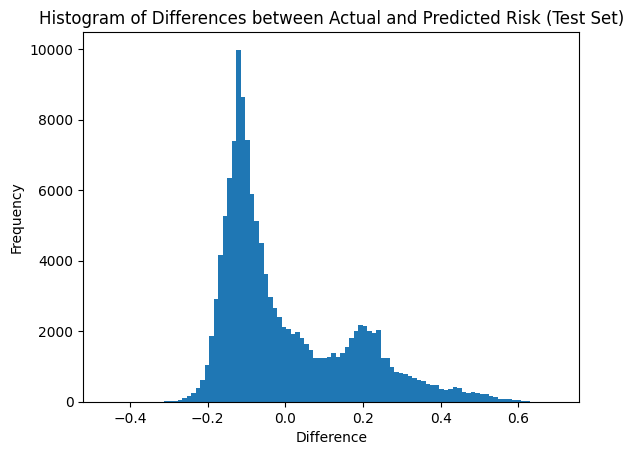

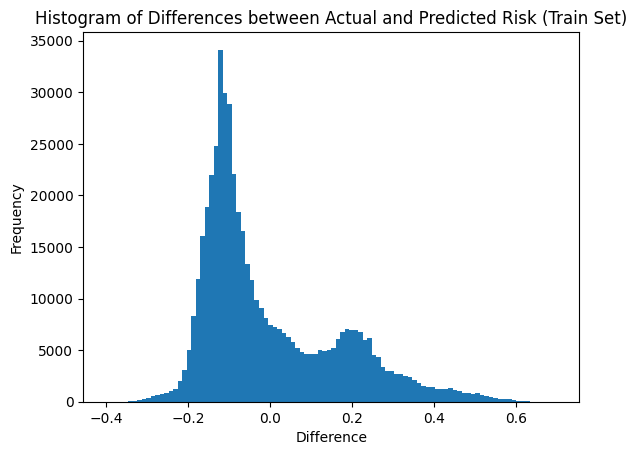

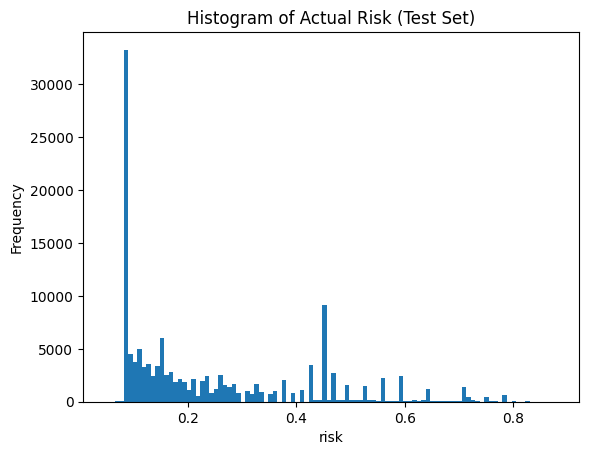

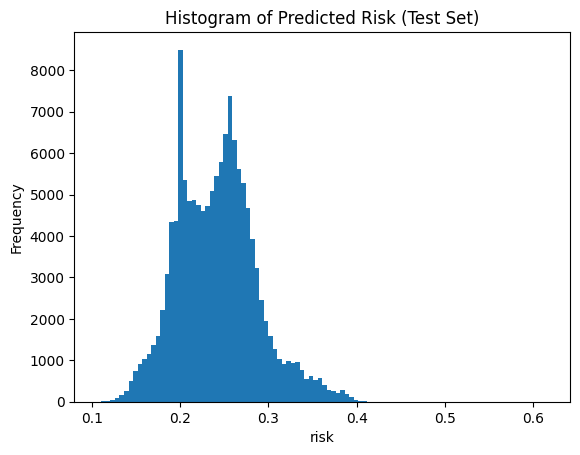

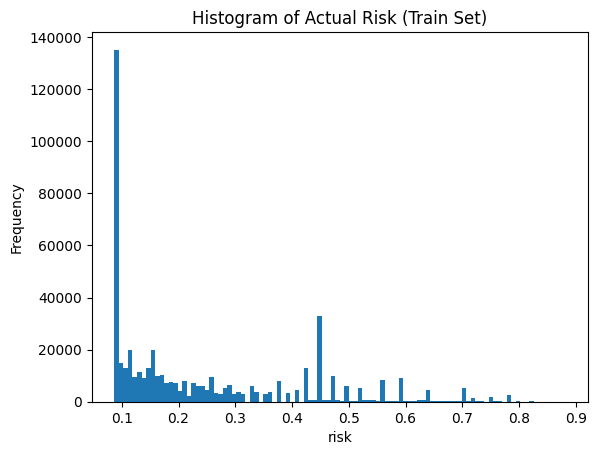

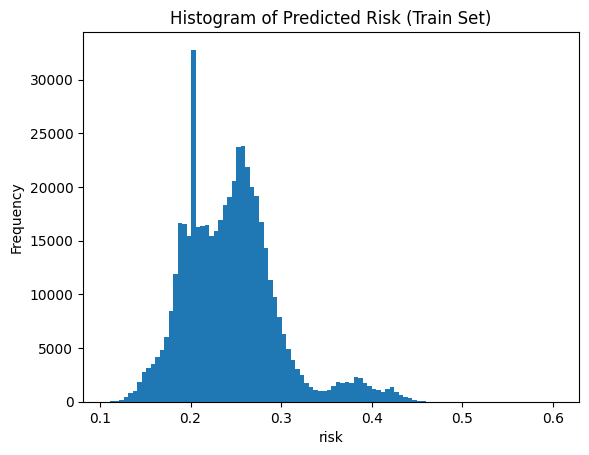

Training MSE: 0.028364300116096842
0.0850067271247571
0.08303605481307041


In [20]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
df_test = pd.DataFrame(Y_test)
df_test['1'] = nn.predict(X_scaled_test)
df_train = pd.DataFrame(Y)
df_train['1'] = nn.predict(X_scaled) 
difference_test=df_test[int('0')] - df_test['1']
differemce_train=df_train[int('0')] - df_train['1']
plt.hist(difference_test, bins=100)
plt.title('Histogram of Differences between Actual and Predicted Risk (Test Set)')
plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.show()
plt.hist(differemce_train, bins=100)
plt.title('Histogram of Differences between Actual and Predicted Risk (Train Set)')
plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.show()

plt.hist(df_test[int('0')], bins=100)
plt.title('Histogram of Actual Risk (Test Set)')
plt.xlabel('risk')
plt.ylabel('Frequency')
plt.show()
plt.hist(df_test['1'], bins=100)
plt.title('Histogram of Predicted Risk (Test Set)')
plt.xlabel('risk')
plt.ylabel('Frequency')
plt.show()

plt.hist(df_train[int('0')], bins=100)
plt.title('Histogram of Actual Risk (Train Set)')
plt.xlabel('risk')
plt.ylabel('Frequency')
plt.show()
plt.hist(df_train['1'], bins=100)
plt.title('Histogram of Predicted Risk (Train Set)')
plt.xlabel('risk')
plt.ylabel('Frequency')
plt.show()
print("Training MSE:",NeuralNetworkScratch.mse(nn,Y_test,nn.predict(X_scaled_test)))
print(r2_score(df_train[0], df_train['1']))
print(r2_score(df_test[0], df_test['1']))

## Using reference

In [21]:
from util.filter_data import filtering
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

df = filtering('src/claims_train.csv', alpha=2, gamma=0.1, train=True)

Y = df['Risk'].values.astype(np.float32).reshape(-1, 1)
df_clean = df.drop(columns=["IDpol", "ClaimNb", "Exposure","Region",'Risk'])
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df_clean.select_dtypes(include=["object", "category"]).columns

X_cat = pd.get_dummies(df_clean[categorical_cols], drop_first=True)
df_clean = df_clean.drop(columns=categorical_cols)
X_final = np.hstack([df_clean, X_cat.values])

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final).astype(np.float32)

# Flatten Y
y_flat = Y.ravel()


c:\Users\takac\ITU\semester3\machine\machine-n-learnings-inc\util\filter_data.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Region', group_keys=False).apply(remove_outliers)


In [22]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


# 80/20 train–test split
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, Y, test_size=0.2, random_state=42
)

# Define neural network
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='sgd',
    learning_rate_init=0.1,
    max_iter=50,          # number of epochs
    batch_size=100,       # mini-batch size
    random_state=42,
    verbose=True          # prints loss per iteration
)

# Train
mlp.fit(X_train, y_train)

# Predict
y_train_pred = mlp.predict(X_train)
y_val_pred   = mlp.predict(X_val)

# Compute MSE
mse_train_mlp = mean_squared_error(y_train, y_train_pred)
mse_val_mlp   = mean_squared_error(y_val,   y_val_pred)

print("MLPRegressor train MSE:", mse_train_mlp)
print("MLPRegressor val   MSE:", mse_val_mlp)

c:\Users\takac\miniconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Iteration 1, loss = 0.01463509
Iteration 2, loss = 0.01430306
Iteration 3, loss = 0.01425072
Iteration 4, loss = 0.01423025
Iteration 5, loss = 0.01420676
Iteration 6, loss = 0.01419966
Iteration 7, loss = 0.01418888
Iteration 8, loss = 0.01418101
Iteration 9, loss = 0.01417504
Iteration 10, loss = 0.01416848
Iteration 11, loss = 0.01416688
Iteration 12, loss = 0.01416296
Iteration 13, loss = 0.01415783
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
MLPRegressor train MSE: 0.028875766322016716
MLPRegressor val   MSE: 0.02889503724873066


# M3 method

In [23]:
#Importing the filtering function from util folder
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), "..")))
from util.filter_data import filtering

# Essential libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score

df = filtering("./src/claims_train.csv",train=True)

X = df.drop(columns=["ClaimNb", "Exposure", "Risk"])
y = df["Risk"]

# Identify column types
categorical_cols = X.select_dtypes(include=["object", "category"]).columns
numeric_cols = X.select_dtypes(include=["number"]).columns

# Preprocessing pipeline: OneHot + Scaling
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit and transform training data, transform validation data
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

NameError: name '__file__' is not defined

In [ ]:
# Train Random Forest Regressor
#Used grid search to find the best hyperparameters for the random forest model
rf = RandomForestRegressor(
    n_estimators=2500,
    max_depth=None,
    min_samples_split=200,
    min_samples_leaf=100,
    max_features=0.4,
    bootstrap=True,
    max_samples=0.9,
    oob_score=True,
    criterion='squared_error',
    random_state=42
)

rf.fit(X_train_processed, y_train)

# Evaluate on validation set
y_pred = rf.predict(X_val_processed)
mse = mean_squared_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"Train MSE vs formula: {mse:.4f}")
print(f"Train R² vs formula: {r2:.4f}")

# Evaluate on test set
df_test = filtering("./src/claims_test.csv",train=False)

X_test = df_test.drop(columns=["ClaimNb", "Exposure", "Risk"])
y_test = df_test["Risk"]

X_test_processed = preprocessor.transform(X_test)

y_pred_test = rf.predict(X_test_processed)
                                                                     
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"Test MSE vs formula: {mse_test:.4f}")
print(f"Test R² vs formula: {r2_test:.4f}")